In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

**Task 1 : Exploratory Data Analysis (EDA)**

In [3]:
train_data_dir = './Combined/Train'

assert os.path.isdir(train_data_dir), 'Training directory does not exist'

path_train = {}

for activity in os.listdir(train_data_dir):
    path_train[activity] = f'{train_data_dir}/{activity}/{min(os.listdir(f'{train_data_dir}/{activity}'))}'

1. Plot the waveform for one sample data from each activity class. Are you able to see any difference/similarities between the activities? You can plot a subplot having 6 columns to show differences/similarities between the activities. Do you think the model will be able to classify the activities based on the data? [0.5 marks]

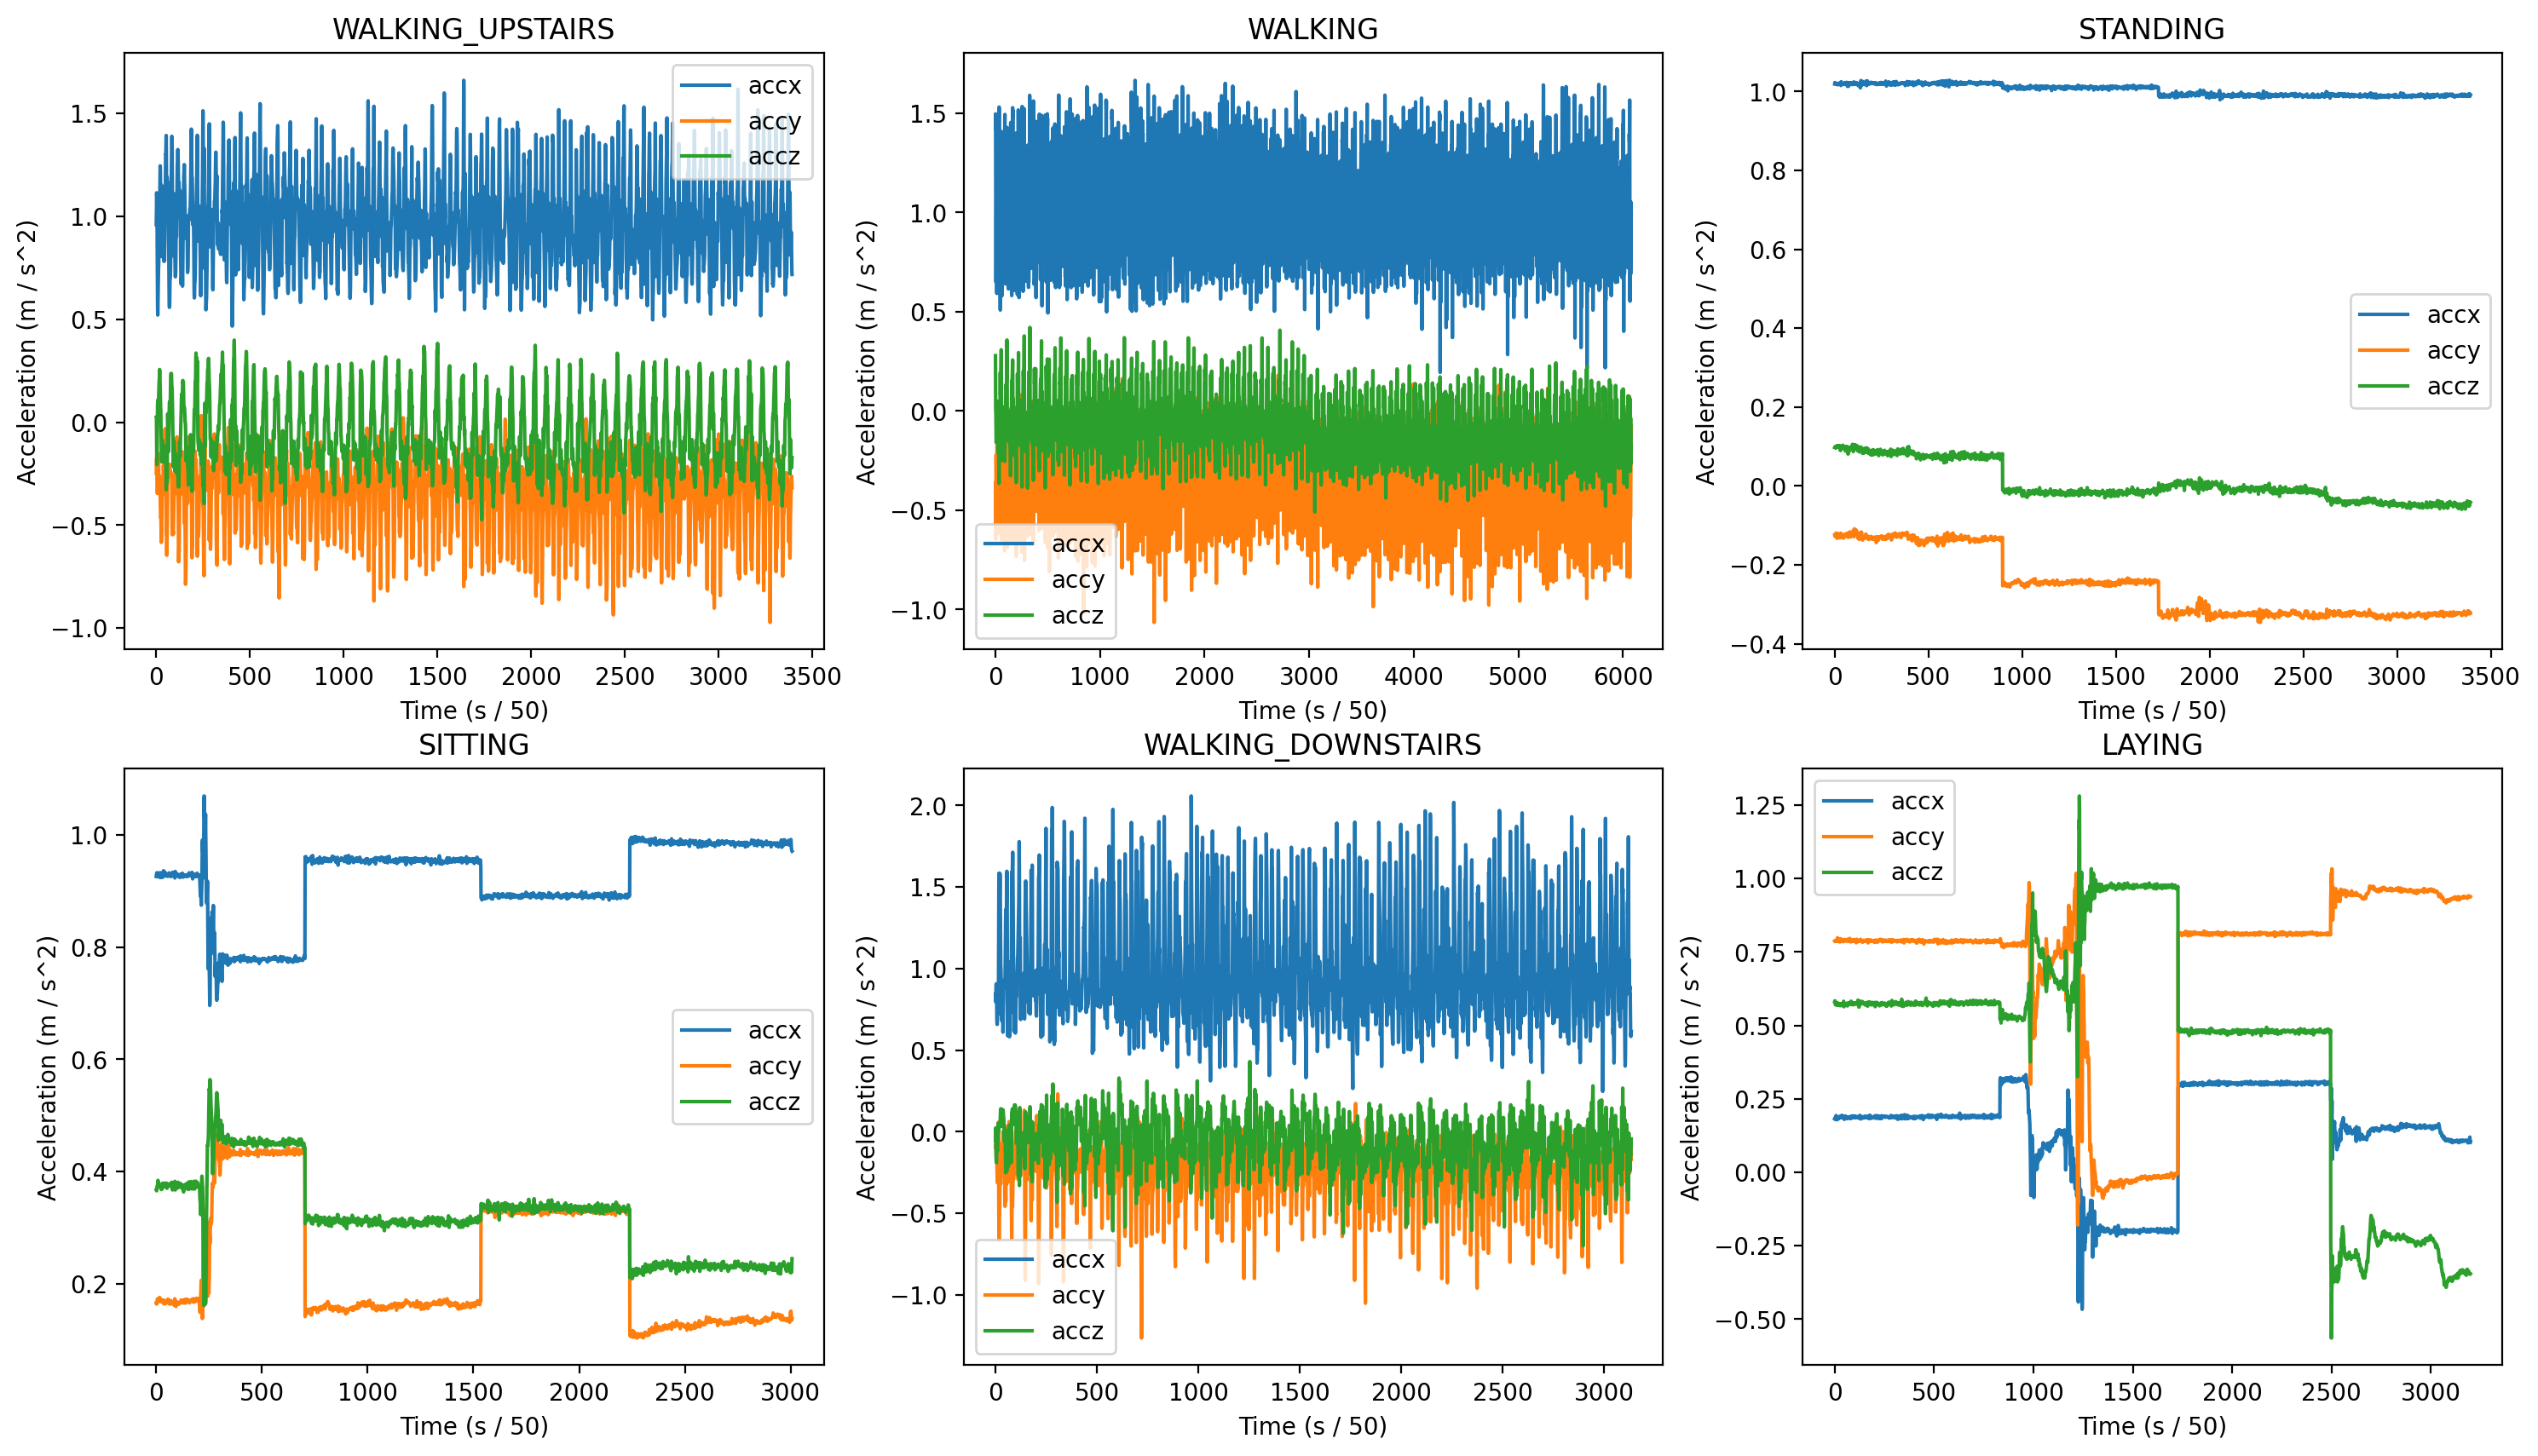

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (activity, path) in enumerate(path_train.items()):
    df = pd.read_csv(path)
    axes[i].plot(df['accx'], label='accx')
    axes[i].plot(df['accy'], label='accy')
    axes[i].plot(df['accz'], label='accz')
    axes[i].set_title(activity)
    axes[i].legend()
    axes[i].set_xlabel('Time (s / 50)')
    axes[i].set_ylabel('Acceleration (m / s^2)')

Sitting and Laying show relatively low change in the accelerometer readings across all axes (accx, accy, accz) compared to Walking, Walking upstairs, Walking downstairs.

Standing shows a nearly constant value of accelerometer reading for (accx, accy, accz) and almost no fluctuations.

Walking, Walking Upstairs, and Walking Downstairs: These activities show more dynamic changes with bigger changes in the accelerometer readings. The waveforms for these activities are more complex and fluctuating compared to the stationary activities. The waveforms of these 3 activities are quite similar to each other, which could indicate that it would be difficult to differentiate between these activities.

The model might misclassify the data as the patterns are mostly similar between Walking, Walking Upstairs, and Walking Downstairs, and between Sitting, Standing and Laying as well.

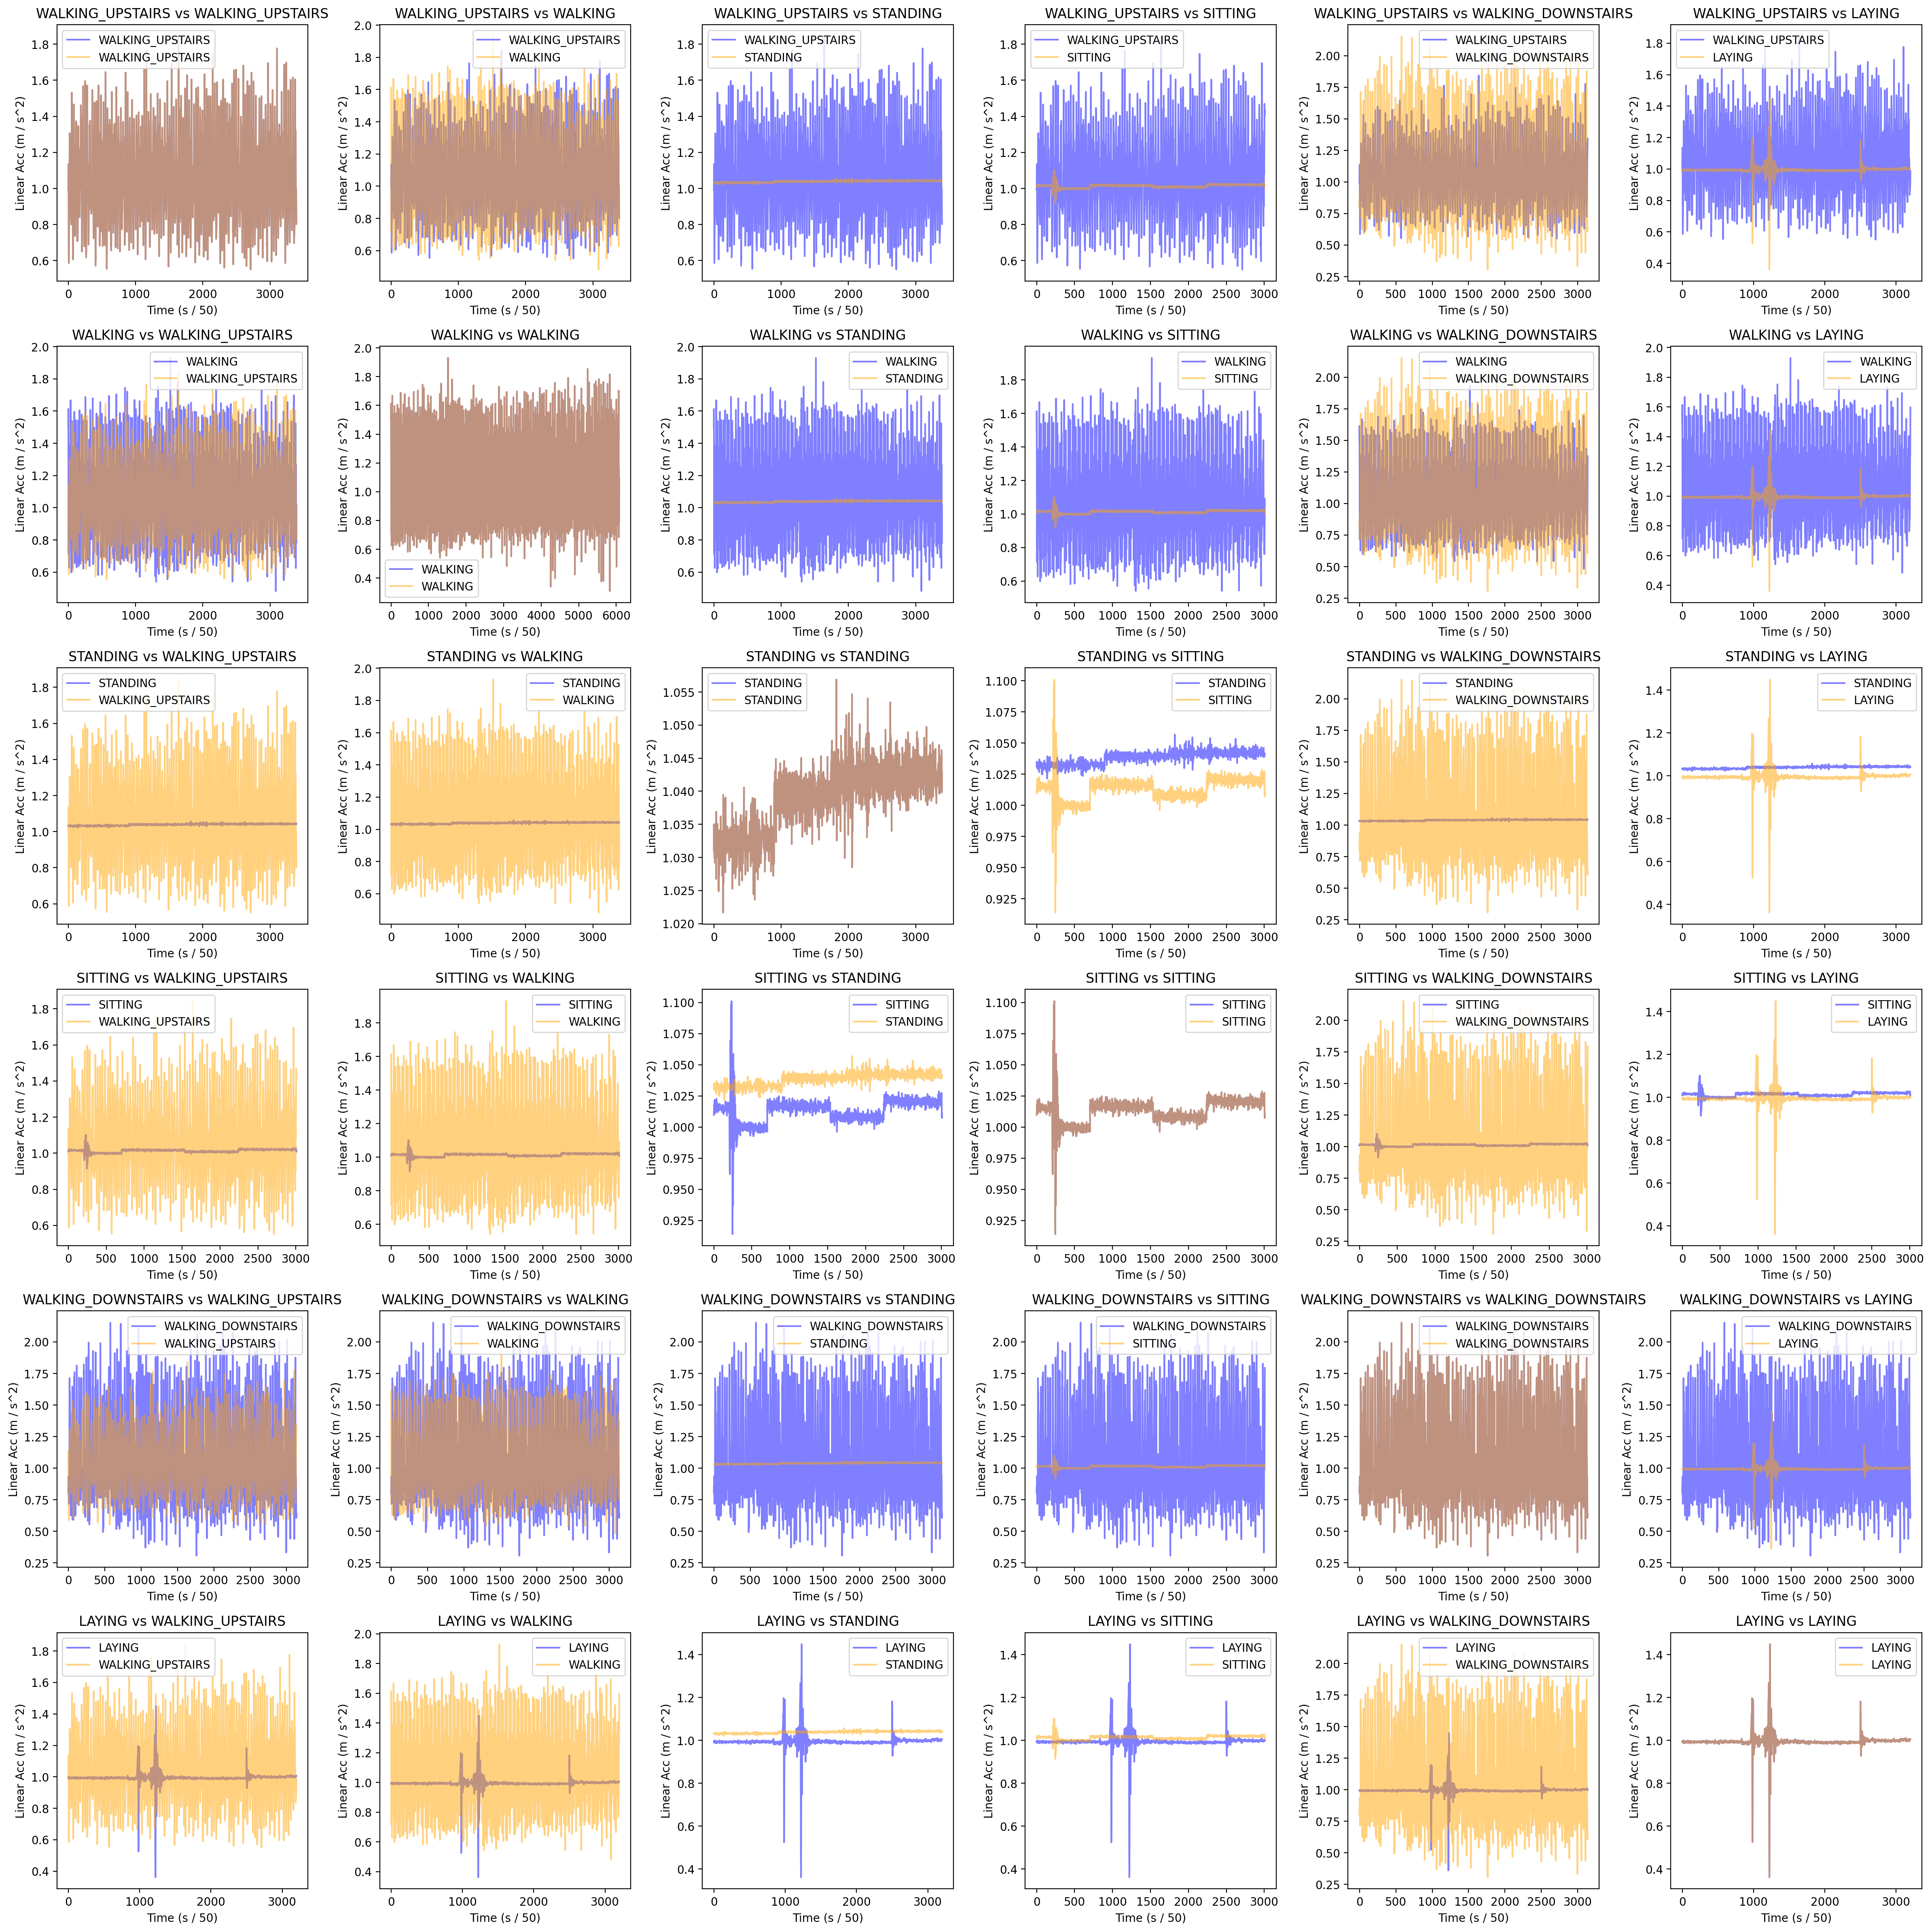

In [5]:
activities = list(path_train.keys())
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 24))
axes = axes.flatten()

for i, activity1 in enumerate(activities):
    df1 = pd.read_csv(path_train[activity1])
    df1['linear_acc'] = np.sqrt(df1['accx'] ** 2 + df1['accy'] ** 2 + df1['accz'] ** 2)

    for j, activity2 in enumerate(activities):
        df2 = pd.read_csv(path_train[activity2])
        df2['linear_acc'] = np.sqrt(df2['accx'] ** 2 + df2['accy'] ** 2 + df2['accz'] ** 2)

        min_length = min(len(df1['linear_acc']), len(df2['linear_acc']))
        linear_acc1 = df1['linear_acc'][:min_length]
        linear_acc2 = df2['linear_acc'][:min_length]

        axes[i * 6 + j].plot(linear_acc1, color='blue', label=activity1, alpha=0.5)
        axes[i * 6 + j].plot(linear_acc2, color='orange', label=activity2, alpha=0.5)
        axes[i * 6 + j].set_title(f'{activity1} vs {activity2}')
        axes[i * 6 + j].set_xlabel('Time (s / 50)')
        axes[i * 6 + j].set_ylabel('Linear Acc (m / s^2)')
        axes[i * 6 + j].legend()

plt.tight_layout()
plt.show()

2.Do you think we need a machine learning model to differentiate between static activities (laying, sitting, standing) and dynamic activities(walking, walking_downstairs, walking_upstairs)? Look at the linear acceleration for each activity and justify your answer. [0.5 marks]

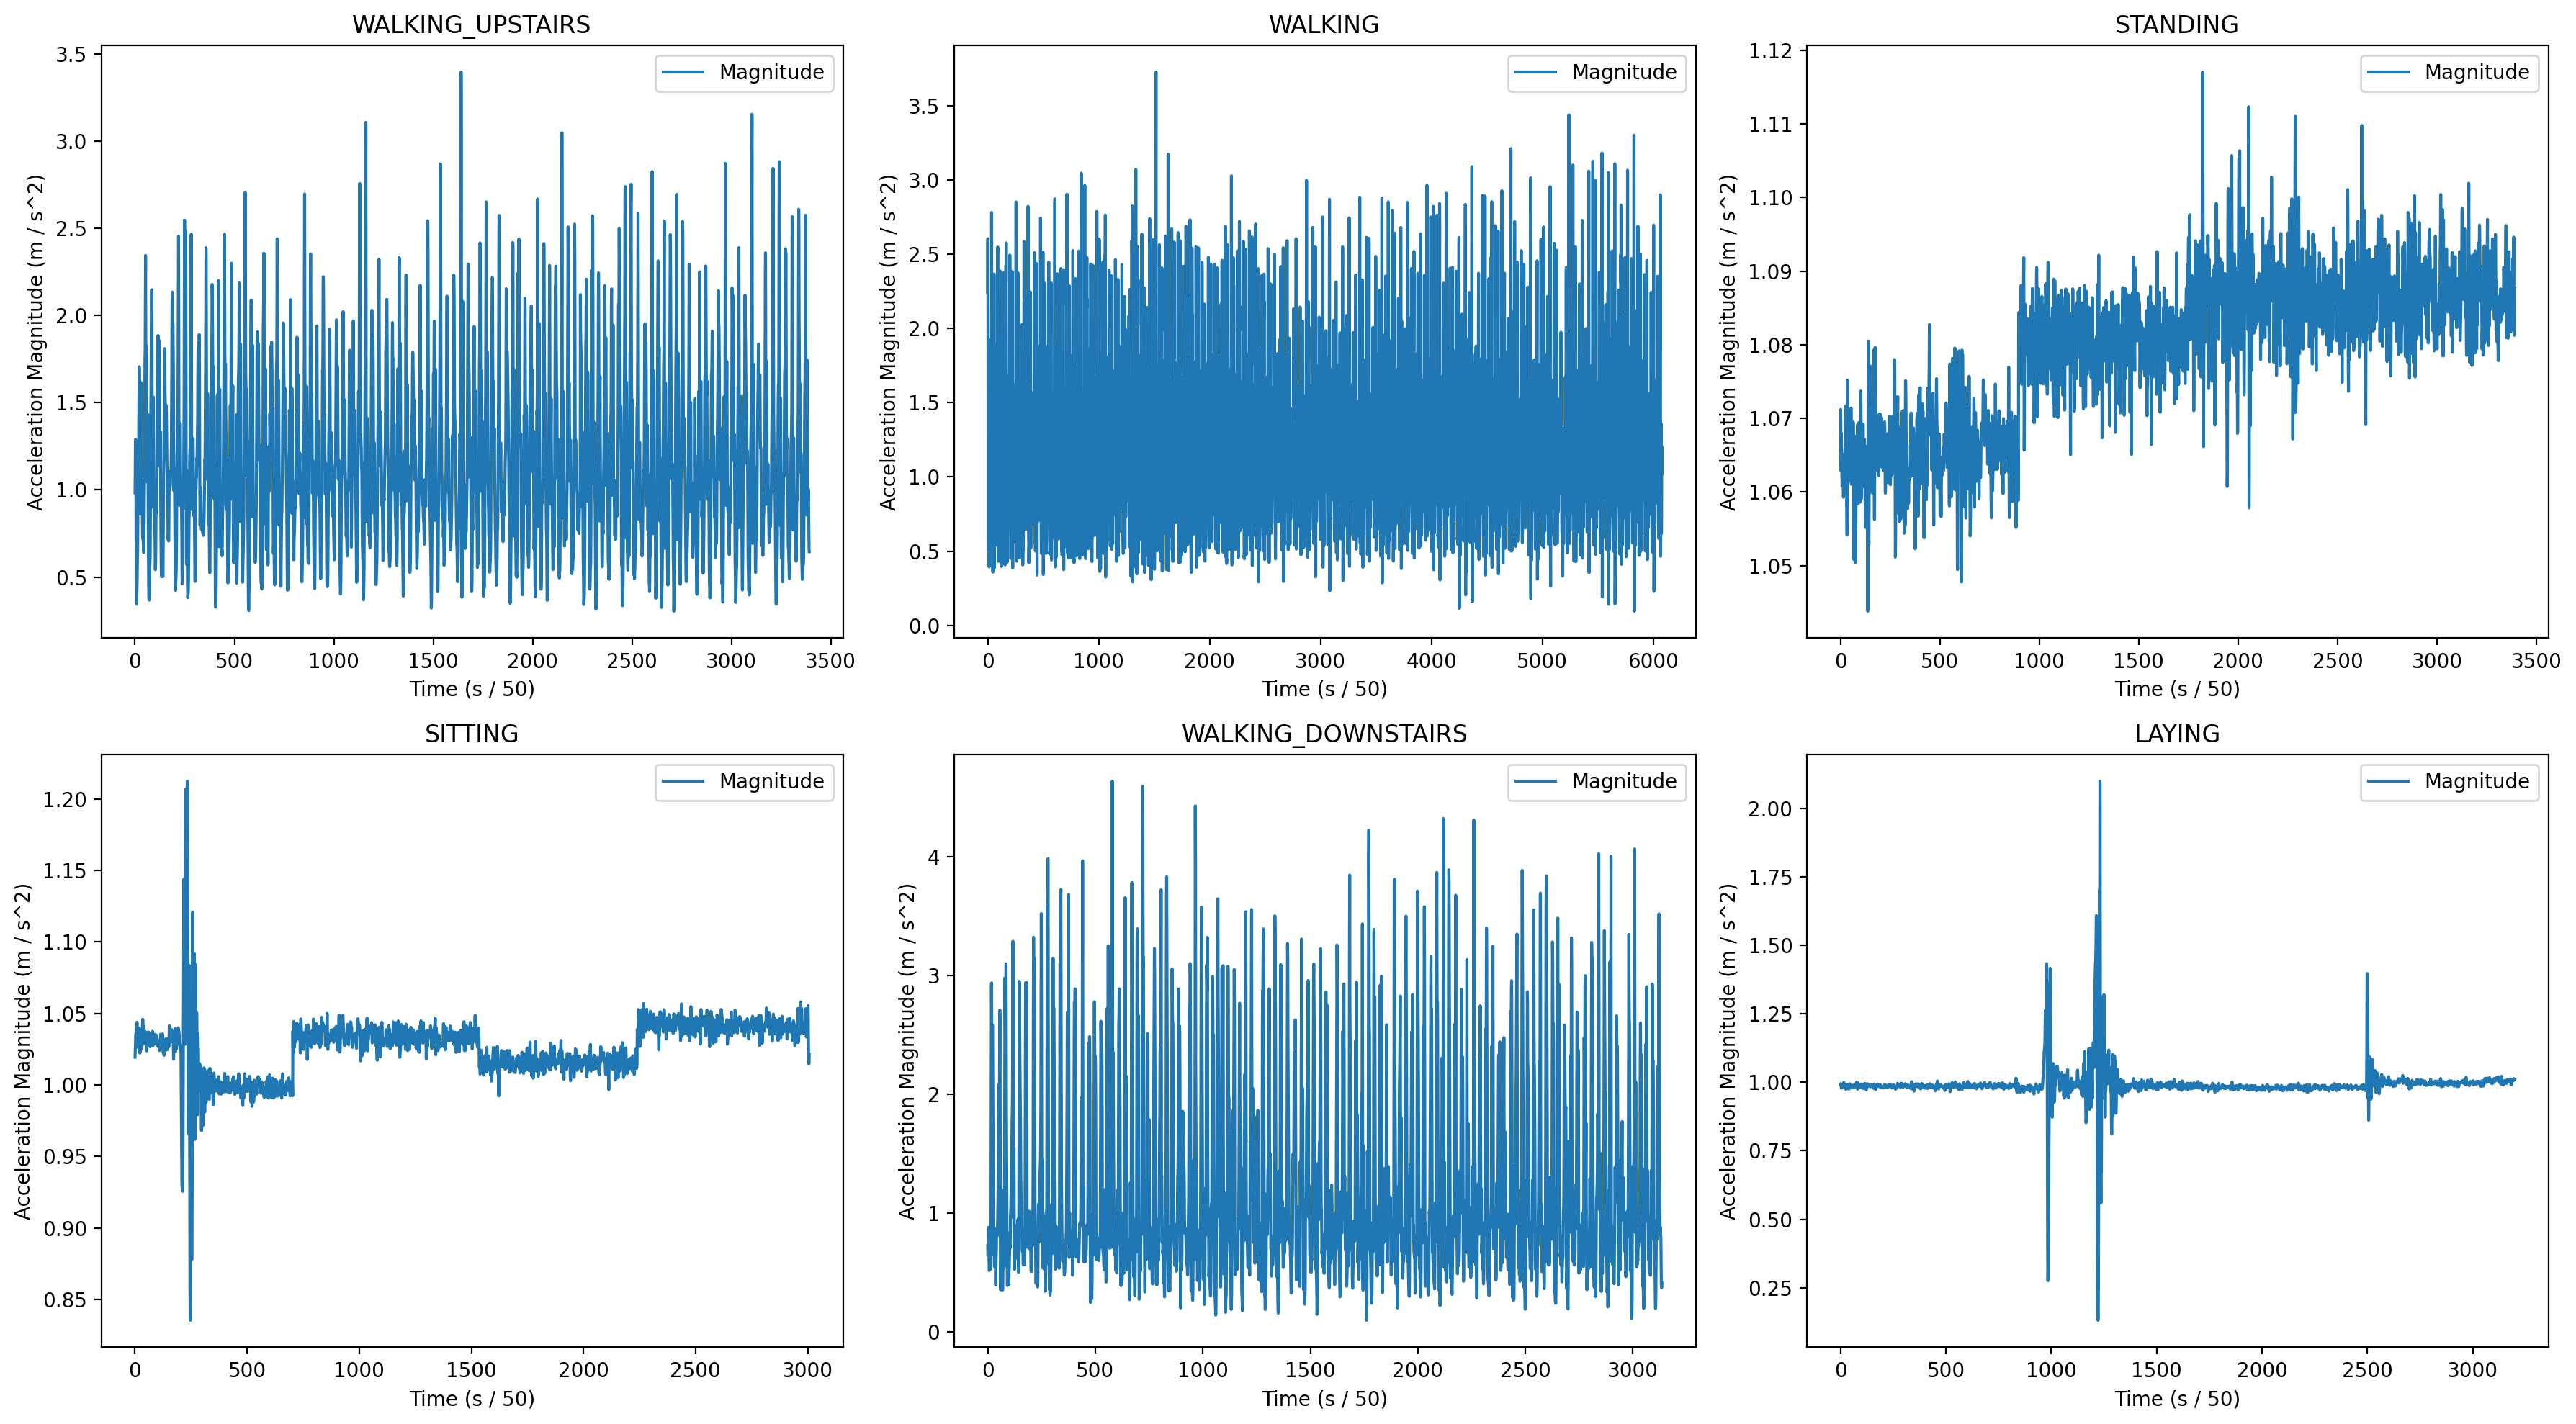

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (activity, path) in enumerate(path_train.items()):
    df = pd.read_csv(path)

    df['magnitude'] = (df['accx'] ** 2 + df['accy'] ** 2 + df['accz'] ** 2)

    axes[i].plot(df['magnitude'], label='Magnitude')
    axes[i].set_title(activity)
    axes[i].legend()
    axes[i].set_xlabel('Time (s / 50)')
    axes[i].set_ylabel('Acceleration Magnitude (m / s^2)')

plt.tight_layout()
plt.show()

The linear acceleration for Static Activities (Laying, Sitting, Standing shows very little variation. While Dynamic Activities (Walking, Walking Downstairs, Walking Upstairs) shows a lot of changes in linear acceleration, they have more complex and fluctuating pattern. By plotting the graph we can easily distinguish between the dynamic and static activities.

So In conclusion, No, we likely do not need a machine learning model to differentiate between static activities and dynamic activities. By using proper features, it should be possible to directly classify between static and dynamic activities.

3.Visualize the data using PCA. [1 marks]

a) Use PCA (Principal Component Analysis) on Total Acceleration to compress the acceleration timeseries into two features and plot a scatter plot to visualize different class of activities.

In [6]:
def pca(X, n_components=2):
    X_mean_centered = X - np.mean(X, axis=0)

    covariance_matrix = np.cov(X_mean_centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1][:n_components]
    eigenvector_subset = eigenvectors[:, sorted_indices]

    X_pca = np.dot(X_mean_centered, eigenvector_subset)
    return X_pca

In [7]:
activity_labels = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

In [8]:
from MakeDataset import X_train, y_train, X_test

Training data shape:  (126, 500, 3)
Testing data shape:  (54, 500, 3)


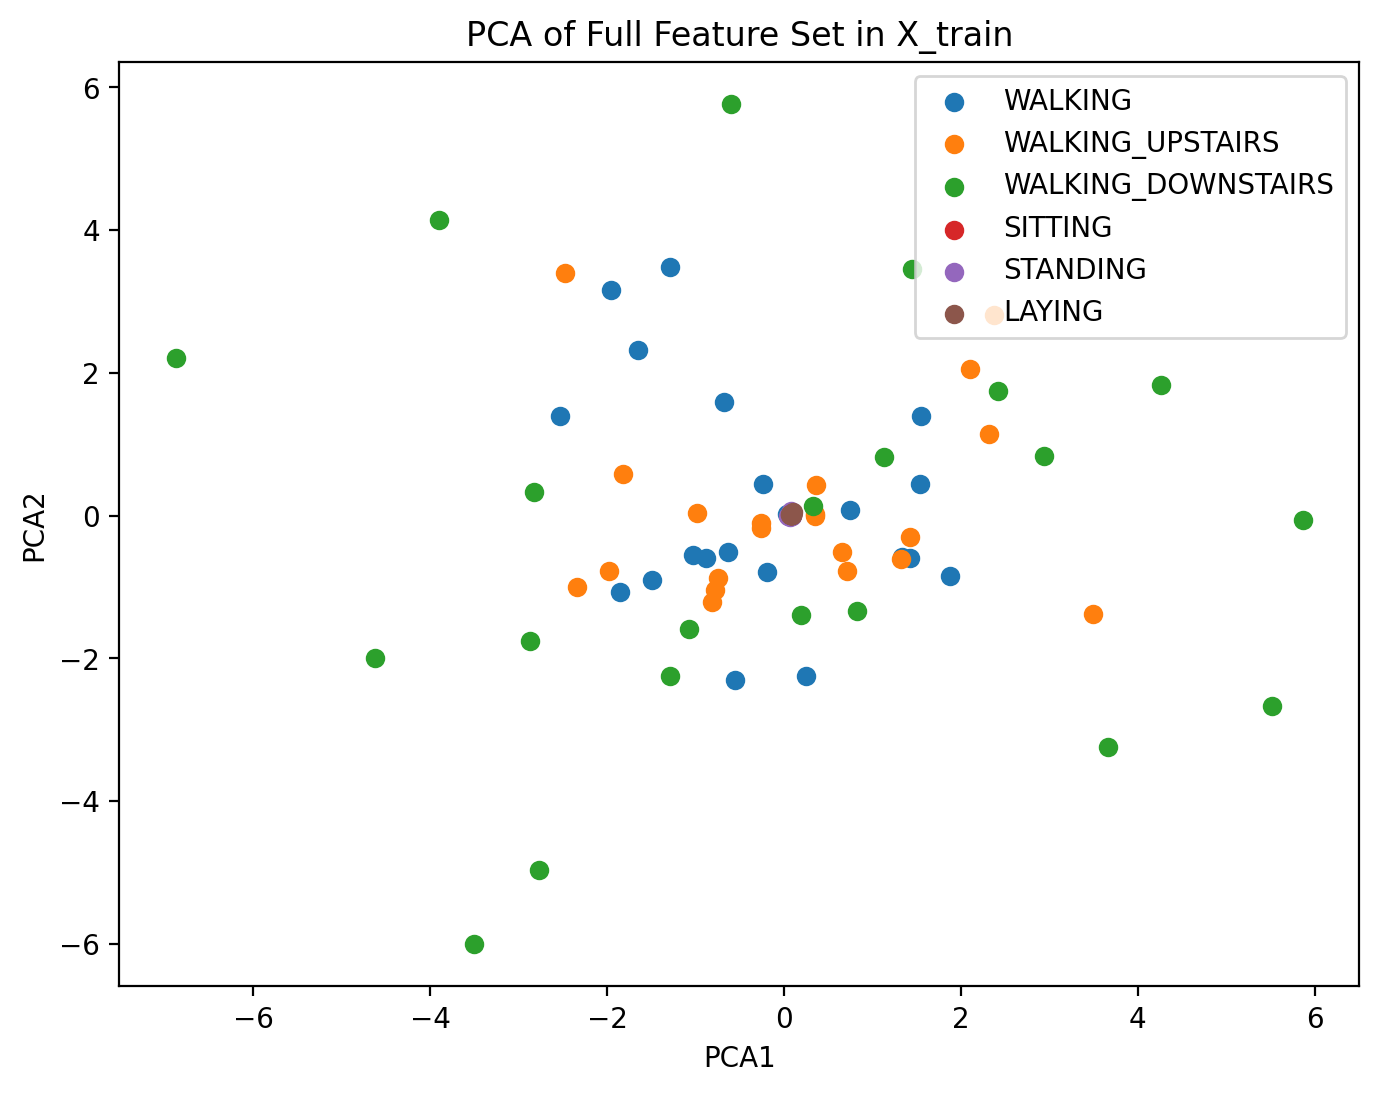

In [9]:
X_train_magnitude = np.linalg.norm(X_train, axis=2)
X_test_magnitude = np.linalg.norm(X_test, axis=2)

df_train_2a = pd.DataFrame(data=X_train_magnitude)
df_test_2a = pd.DataFrame(data=X_test_magnitude)

x_train_pca = pca(X_train_magnitude, n_components=2)

pca_df_1 = pd.DataFrame(data=x_train_pca, columns=['PCA1', 'PCA2'])
pca_df_1['Activity'] = y_train

plt.figure(figsize=(8, 6))
for activity in np.unique(pca_df_1['Activity']):
    subset = pca_df_1[pca_df_1['Activity'] == activity]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=activity_labels[int(activity)])

plt.title('PCA of Full Feature Set in X_train')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

In [10]:
df_train_2a.to_csv('df_train_2a.csv', index=False)
df_test_2a.to_csv('df_test_2a.csv', index=False)

b) Next, use TSFEL (a featurizer library) to create features (your choice which ones you feel are useful) and then perform PCA to obtain two features. Plot a scatter plot to visualize different class of activities.

In [11]:
from MakeDataset import X_train, y_train, X_test

print(X_train.shape, y_train.shape)

(126, 500, 3) (126,)


In [12]:
import tsfel
import warnings
import pandas as pd

cfg = tsfel.get_features_by_domain()
tsfel_x_train = tsfel.time_series_features_extractor(cfg, X_train)
tsfel_x_test = tsfel.time_series_features_extractor(cfg, X_test)
    
print(tsfel_x_train.shape, tsfel_x_test.shape)

/tmp/ipykernel_154631/4089427012.py:6: UserWarning: Using default sampling frequency set in configuration file.
  tsfel_x_train = tsfel.time_series_features_extractor(cfg, X_train)


/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES33

/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES335-Insanity-1/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/features.py:498: FutureWarning: The histogram feature was deprecated in version 0.1.8 and will be replaced by the mode of histogram in 0.1.9. From then on, only a single feature value will be returned.
  warnings.warn(
/home/sriv/PycharmProjects/ES33

(126, 495) (54, 495)


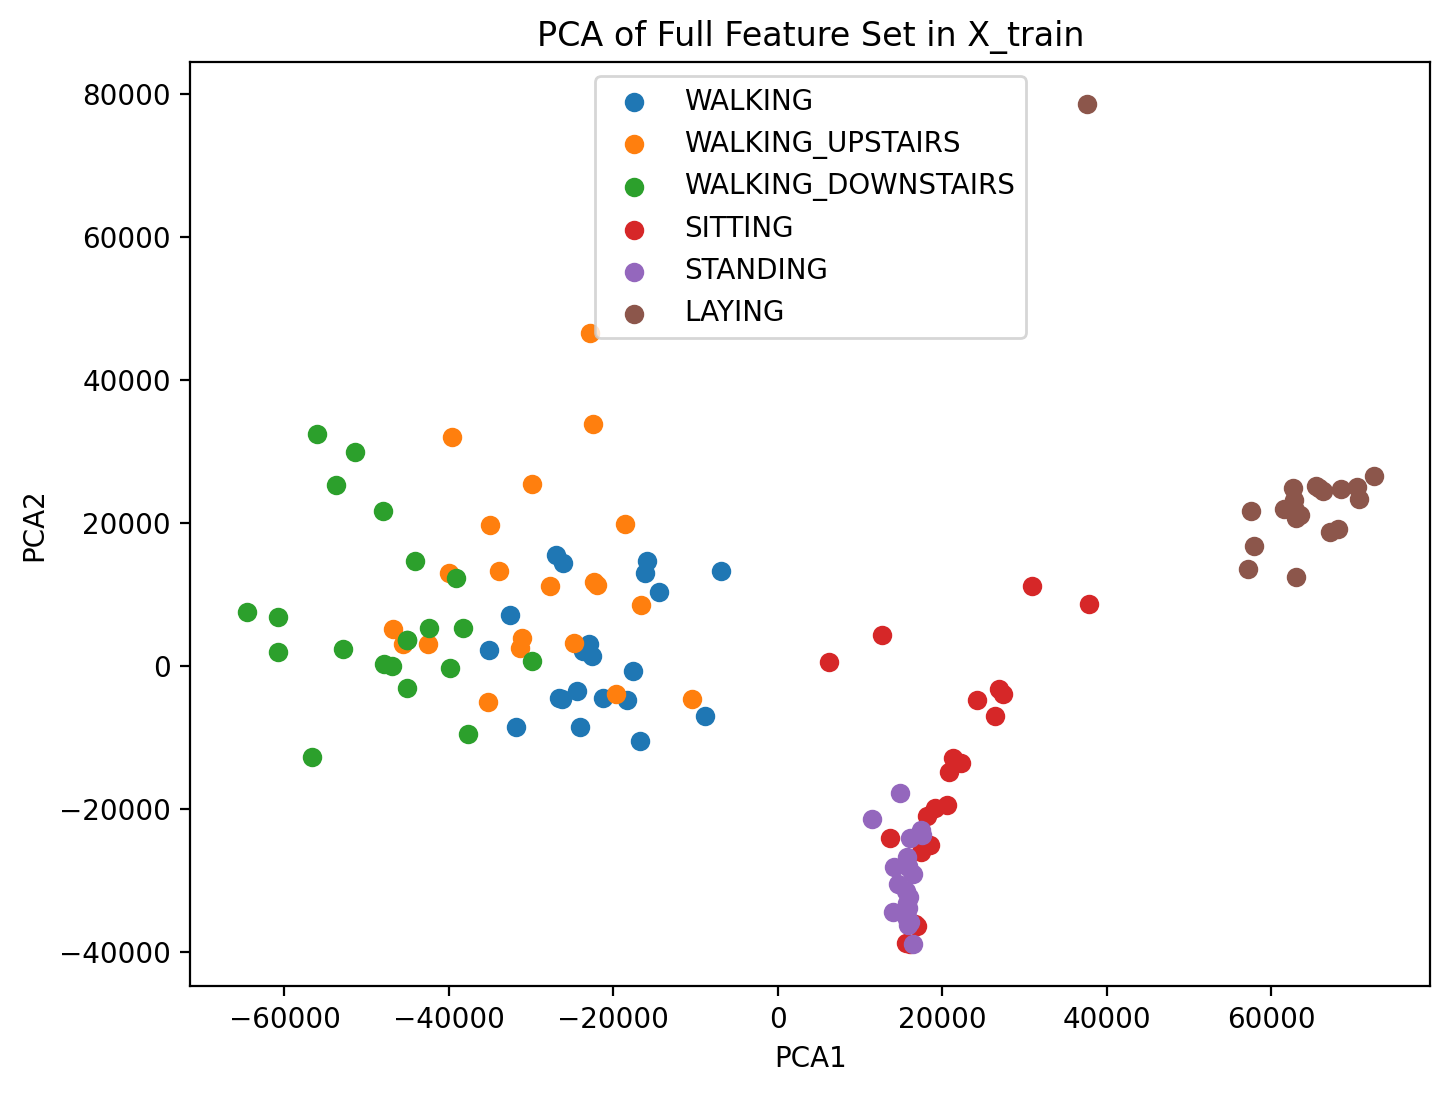

In [13]:
x_train_pca = pca(tsfel_x_train, n_components=2)

pca_df = pd.DataFrame(data=x_train_pca, columns=['PCA1', 'PCA2'])
pca_df['Activity'] = y_train

plt.figure(figsize=(8, 6))
for activity in np.unique(pca_df['Activity']):
    subset = pca_df[pca_df['Activity'] == activity]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=activity_labels[int(activity)])

plt.title('PCA of Full Feature Set in X_train')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

In [14]:
tsfel_x_train.to_csv('tsfel_x_train.csv', index=False)
tsfel_x_test.to_csv('tsfel_x_test.csv', index=False)

c) Now use the features provided by the dataset and perform PCA to obtain two features. Plot a scatter plot to visualize different class of activities.


In [15]:
colors = {
    'WALKING': 'blue',
    'WALKING_UPSTAIRS': 'yellow',
    'WALKING_DOWNSTAIRS': 'red',
    'SITTING': 'purple',
    'STANDING': 'orange',
    'LAYING': 'cyan'
}

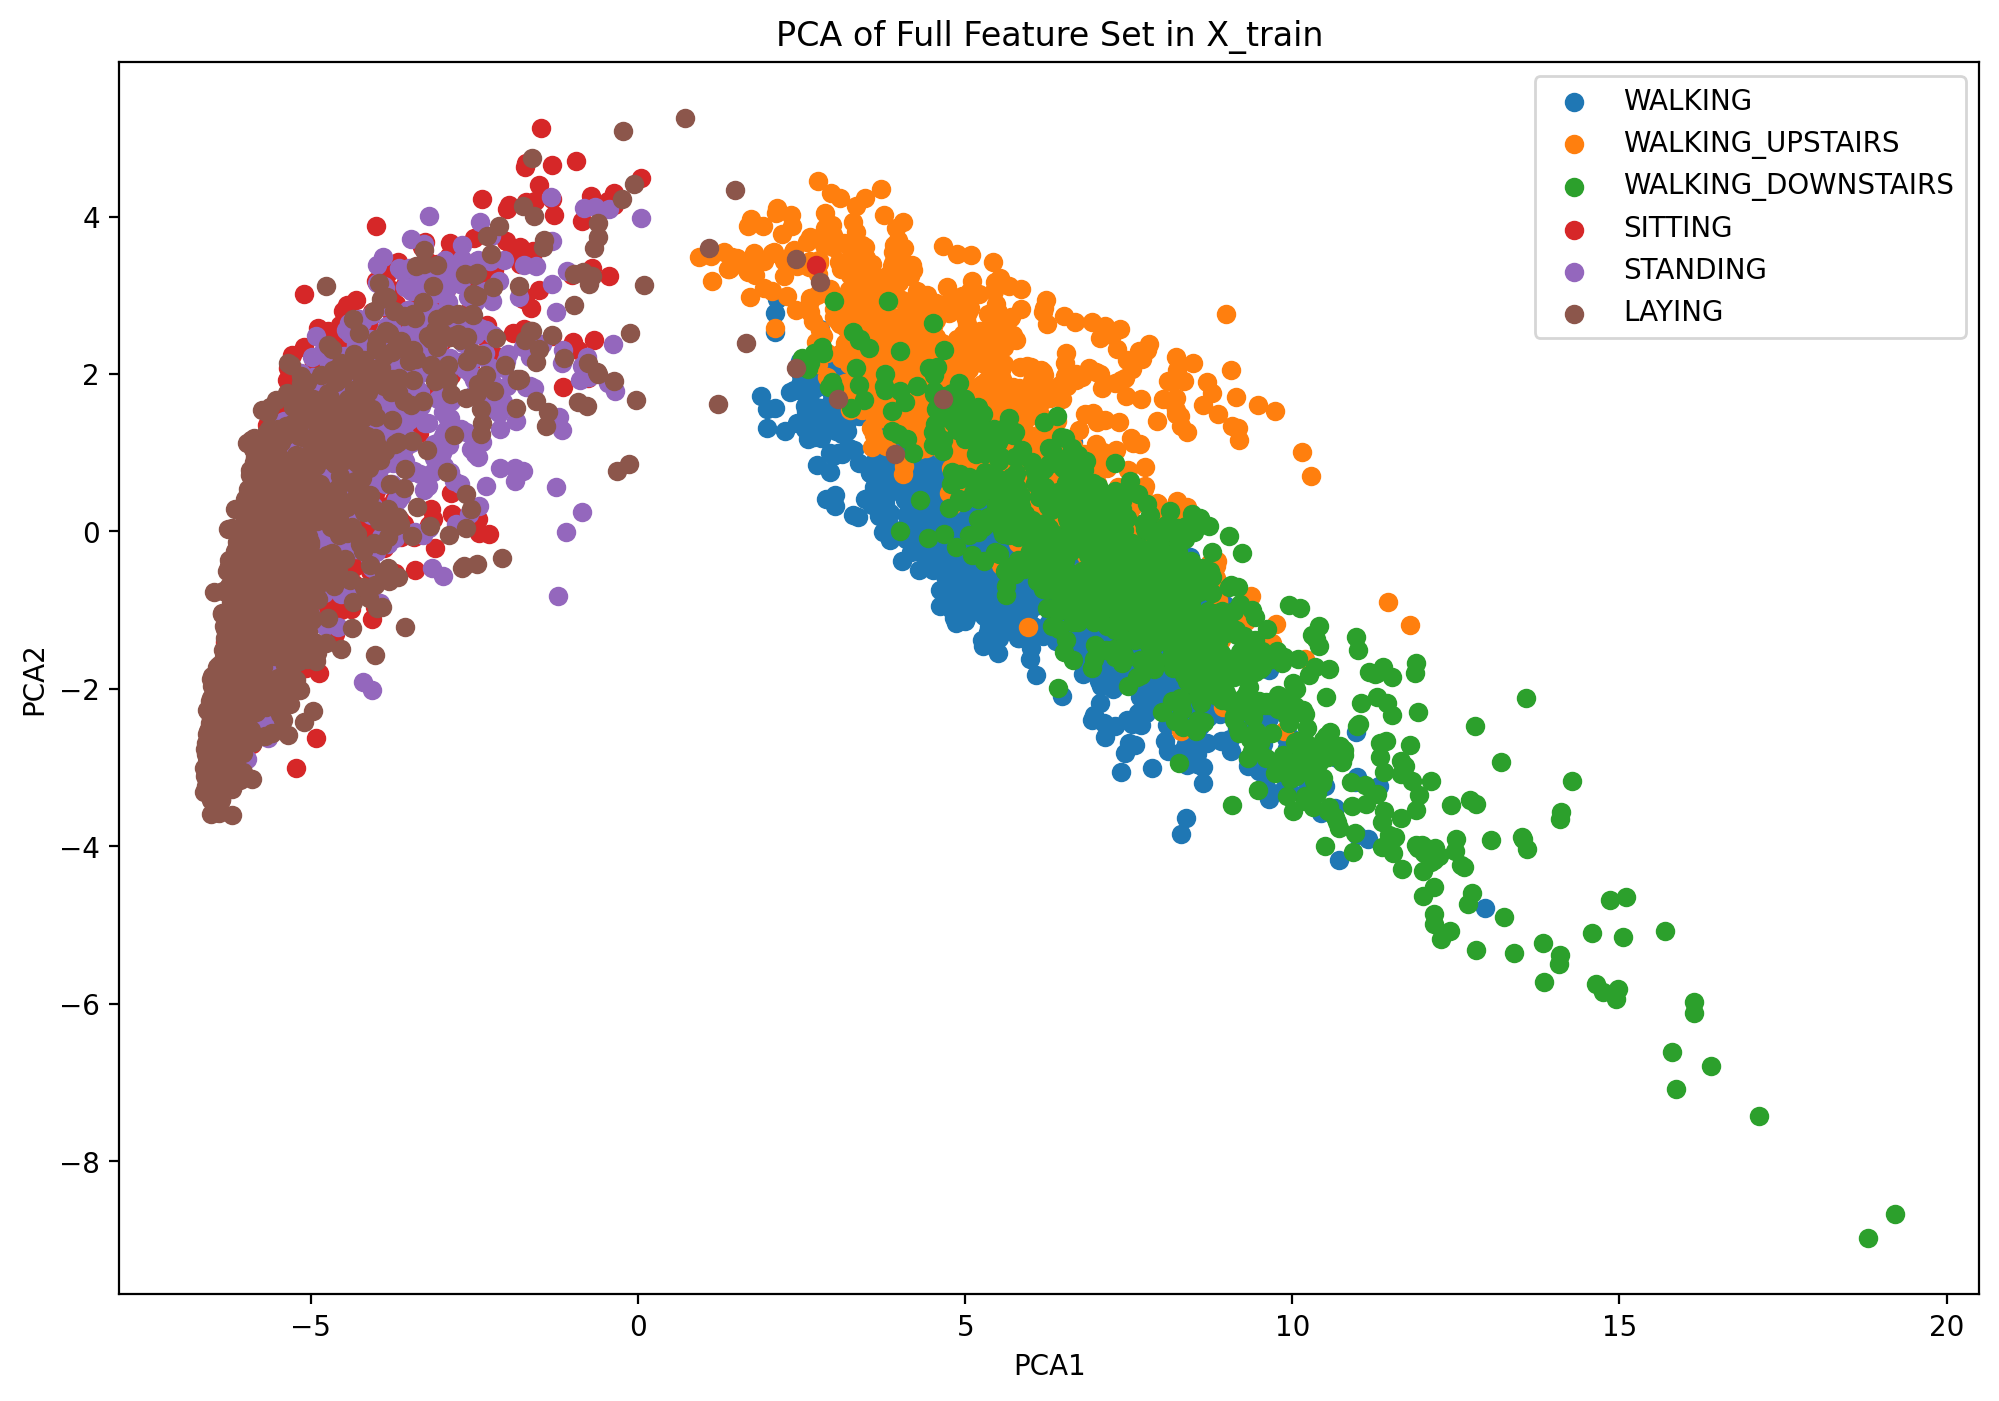

In [16]:
x_train = np.loadtxt('./UCI HAR Dataset/train/X_train.txt')
y_train = np.loadtxt('./UCI HAR Dataset/train/y_train.txt')

x_train_pca = pca(x_train, n_components=2)

pca_df = pd.DataFrame(data=x_train_pca, columns=['PCA1', 'PCA2'])
pca_df['Activity'] = y_train

plt.figure(figsize=(12, 8))
for activity in np.unique(pca_df['Activity']):
    subset = pca_df[pca_df['Activity'] == activity]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=activity_labels[int(activity)])

plt.title('PCA of Full Feature Set in X_train')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()


In [17]:
def pca_plot(x_train, y_train, n_samples=100, n_components=2, n_iter=6):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i in range(n_iter):
        indices = np.random.choice(x_train.shape[0], n_samples, replace=False)
        x_sampled = x_train[indices]
        y_sampled = y_train[indices]

        x_sampled_pca = pca(x_sampled, n_components)

        pca_df = pd.DataFrame(data=x_sampled_pca, columns=['PCA1', 'PCA2'])
        pca_df['Activity'] = y_sampled
        
        for activity in np.unique(pca_df['Activity']):
            subset = pca_df[pca_df['Activity'] == activity]
            axes[i].scatter(subset['PCA1'], subset['PCA2'], label=activity_labels[int(activity)], alpha=0.7)

        axes[i].set_title(f'PCA of Random Sample {i + 1}')
        axes[i].set_xlabel('PCA1')
        axes[i].set_ylabel('PCA2')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

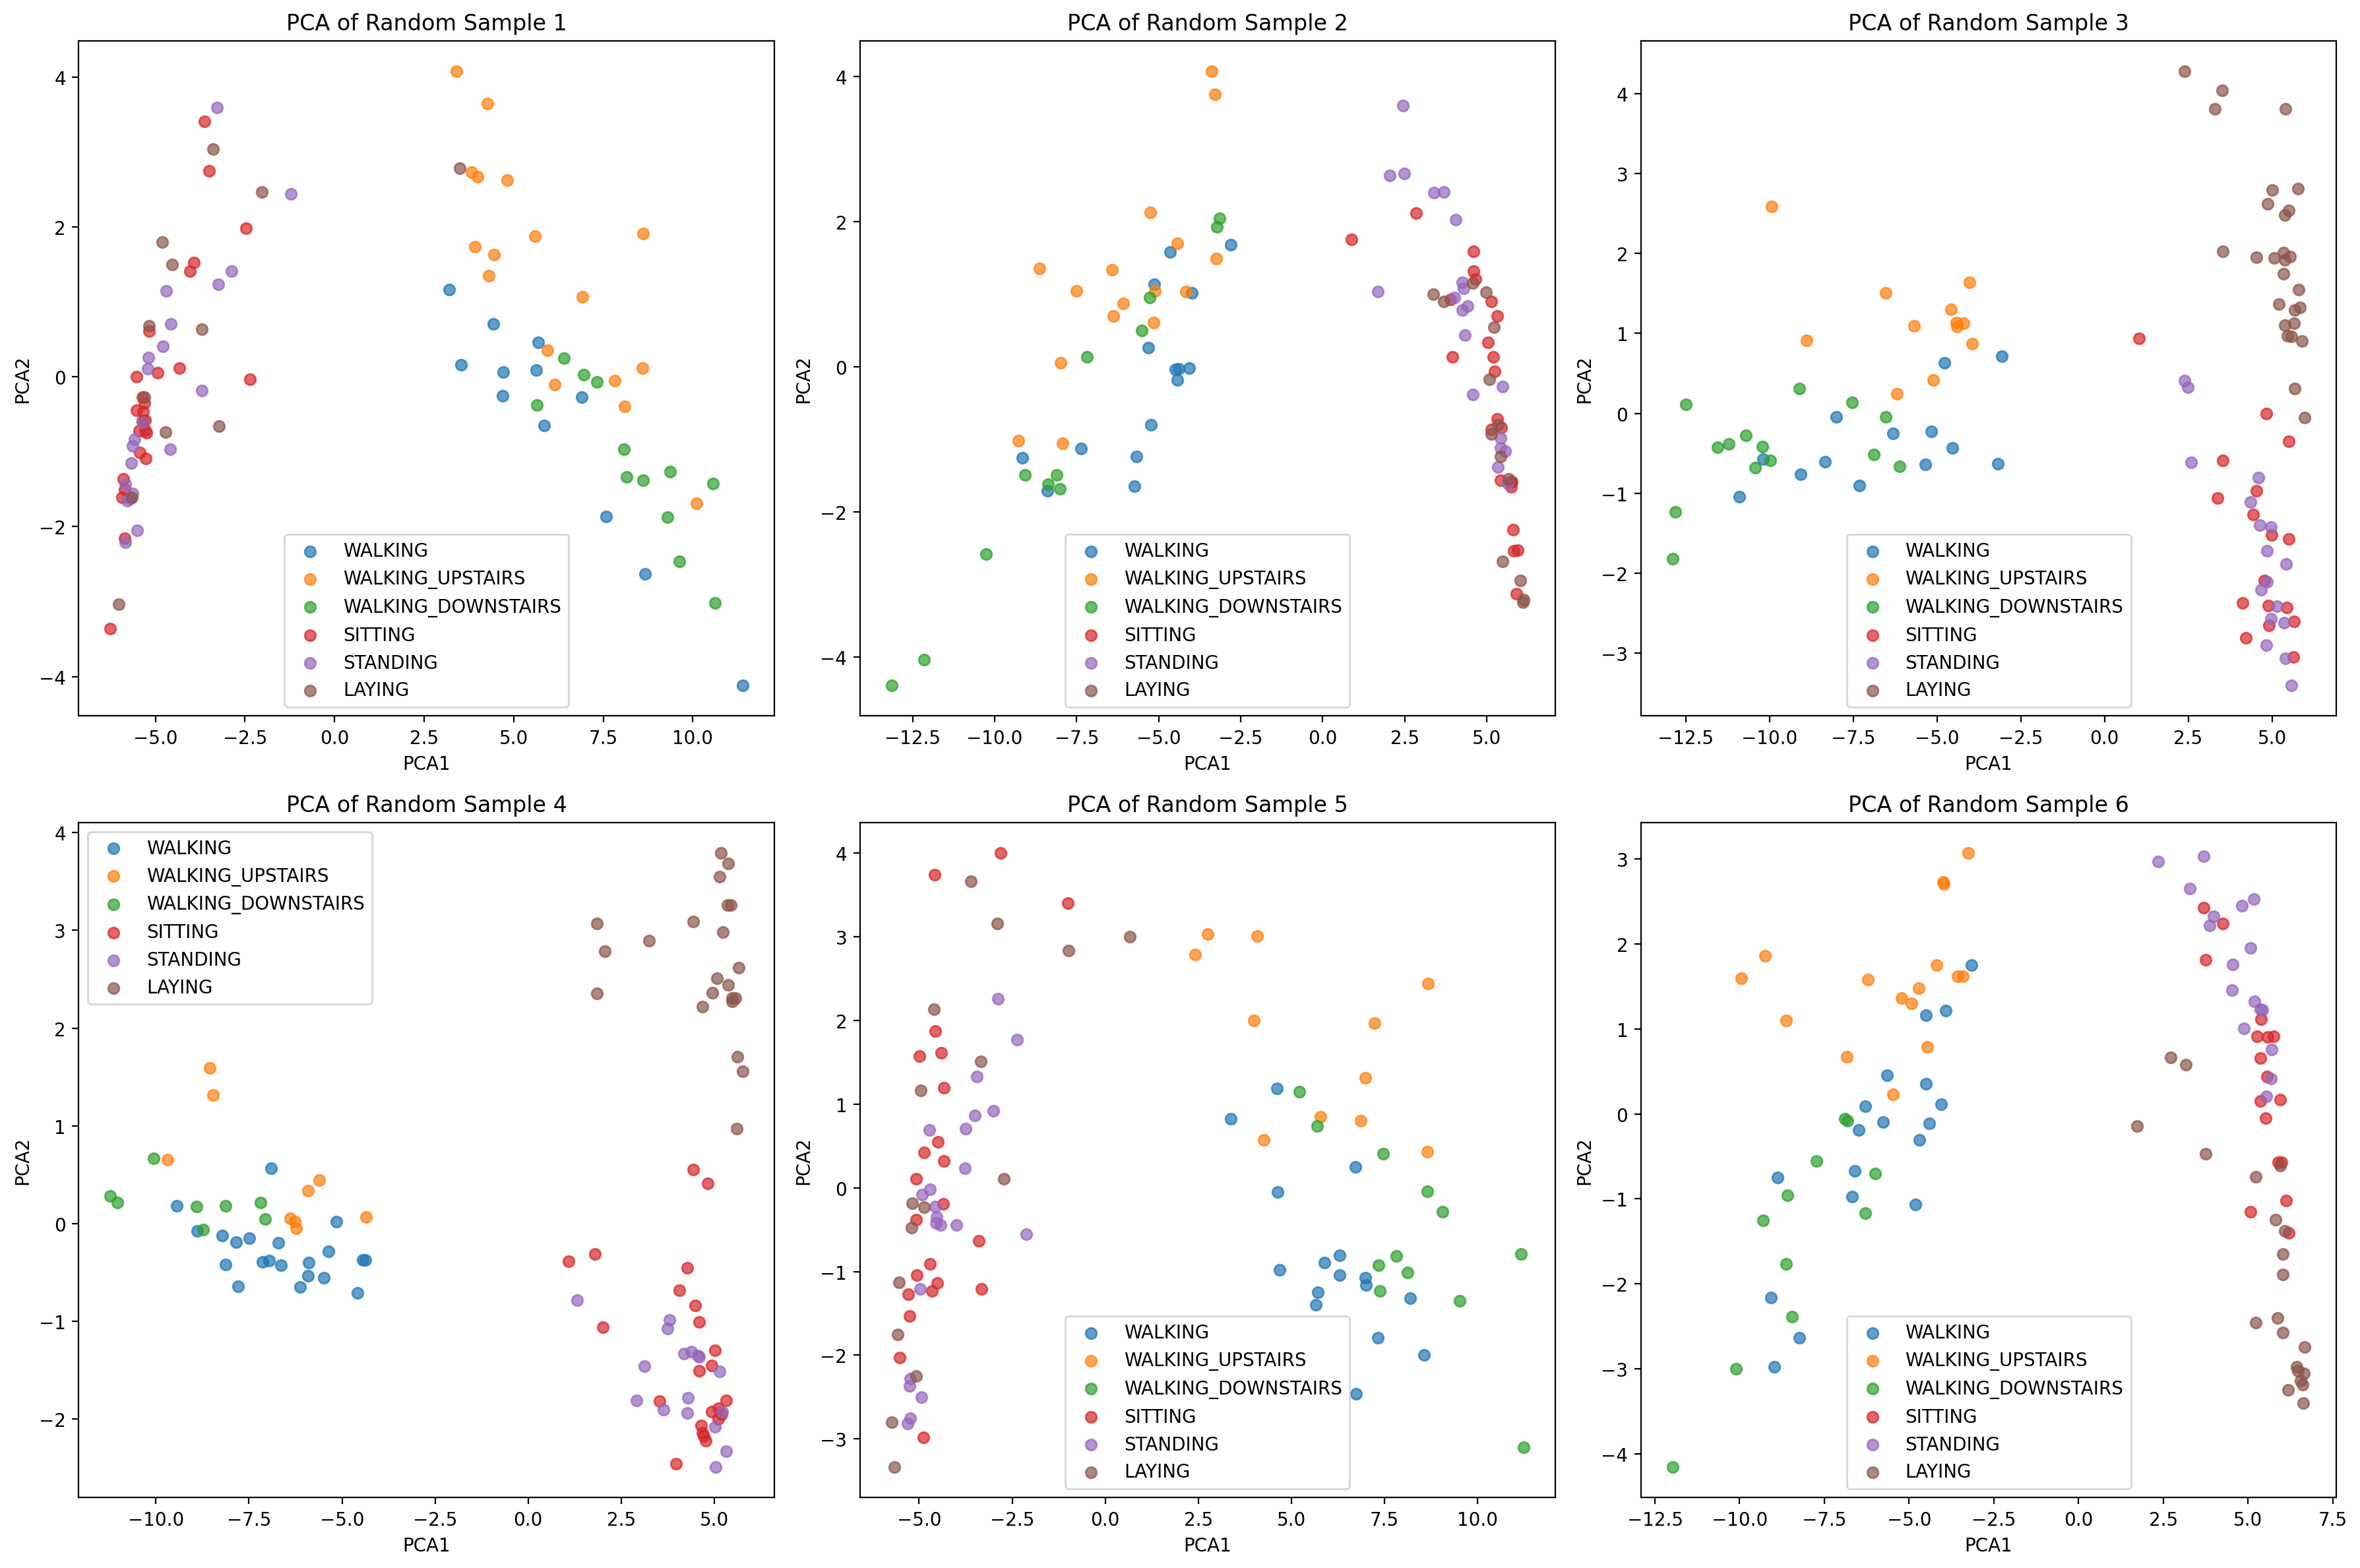

In [18]:
pca_plot(x_train, y_train, n_samples=100, n_components=2, n_iter=6)

d) Compare the results of PCA on Total Acceleration, TSFEL and the dataset features. Which method do you think is better for visualizing the data?

PCA on total acceleration combines the accx, accy, accz into a single value to give a simplified idea about the data distribution. The problem with it is that it might oversimplify the data and as we can see in the plot (a), we can't actually distinguish between the various activities.

PCA on TSFEL is the better for visualizing the data as we can clearly distinguish between various features. As the data is time series TSFEL is a good choice as it can capture the patterns in the data. By doing PCA on the TSFEL features we pick up the important features.

PCA on dataset features also provides a good idea of the data but the visualization might not be like the ones with TSFEL features.

Thus we can conclude that using TSFEL is the better way to visualize the data



4) Calculate the correlation matrix of the features obtained by TSFEL and provided in the dataset. Identify the features that are highly correlated with each other. Are there any redundant features? [1 marks]

In [19]:
import pandas as pd

correlation_matrix = tsfel_x_train.corr()

print(correlation_matrix)

                           0_Absolute energy  0_Area under the curve  \
0_Absolute energy                   1.000000                0.983840   
0_Area under the curve              0.983840                1.000000   
0_Autocorrelation                  -0.319618               -0.293321   
0_Average power                     1.000000                0.983840   
0_Centroid                          0.132061                0.113909   
...                                      ...                     ...   
2_Wavelet variance_4.17Hz           0.255149                0.225867   
2_Wavelet variance_5.0Hz            0.271907                0.237564   
2_Wavelet variance_6.25Hz           0.295275                0.253307   
2_Wavelet variance_8.33Hz           0.327009                0.276397   
2_Zero crossing rate                0.472246                0.383697   

                           0_Autocorrelation  0_Average power  0_Centroid  \
0_Absolute energy                  -0.319618         1.000

In [20]:
threshold = 0.9

redundant_features = {}

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            if feature1 in redundant_features:
                redundant_features[feature1].append(feature2)
            else:
                redundant_features[feature1] = [feature2]

print("Redundant features (correlation > 0.9):")
for feature, redundant in redundant_features.items():
    print(f"{feature} is redundant with {redundant}")


Redundant features (correlation > 0.9):
0_Absolute energy is redundant with ['0_Area under the curve', '0_Average power', '0_ECDF Percentile_1', '0_Mean', '0_Median', '0_Root mean square', '0_Wavelet absolute mean_12.5Hz', '0_Wavelet absolute mean_2.78Hz', '0_Wavelet absolute mean_3.12Hz', '0_Wavelet absolute mean_3.57Hz', '0_Wavelet absolute mean_4.17Hz', '0_Wavelet absolute mean_5.0Hz', '0_Wavelet absolute mean_6.25Hz', '0_Wavelet absolute mean_8.33Hz']
0_Area under the curve is redundant with ['0_Average power', '0_ECDF Percentile_0', '0_ECDF Percentile_1', '0_Mean', '0_Median', '0_Root mean square', '0_Wavelet absolute mean_12.5Hz', '0_Wavelet absolute mean_2.78Hz', '0_Wavelet absolute mean_25.0Hz', '0_Wavelet absolute mean_3.12Hz', '0_Wavelet absolute mean_3.57Hz', '0_Wavelet absolute mean_4.17Hz', '0_Wavelet absolute mean_5.0Hz', '0_Wavelet absolute mean_6.25Hz', '0_Wavelet absolute mean_8.33Hz']
0_Average power is redundant with ['0_ECDF Percentile_1', '0_Mean', '0_Median', '0_R

In [21]:
unique_redundant_features = set(redundant_features.keys())
for redundant_list in redundant_features.values():
    unique_redundant_features.update(redundant_list)

total_redundant_features = len(unique_redundant_features)
print(f"Total number of redundant features: {total_redundant_features}")

Total number of redundant features: 299
